In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt

df = pd.read_csv(r"C:\Users\rraks\Downloads\archive\googleplaystore.csv")


In [12]:
# Check first 5 rows
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [14]:
# Check column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9146 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9146 non-null   object 
 1   Category        9146 non-null   object 
 2   Rating          7730 non-null   float64
 3   Reviews         9146 non-null   object 
 4   Size            9146 non-null   object 
 5   Installs        9146 non-null   object 
 6   Type            9146 non-null   object 
 7   Price           9146 non-null   object 
 8   Content Rating  9145 non-null   object 
 9   Genres          9146 non-null   object 
 10  Last Updated    9146 non-null   object 
 11  Current Ver     9138 non-null   object 
 12  Android Ver     9143 non-null   object 
dtypes: float64(1), object(12)
memory usage: 1000.3+ KB


In [16]:
# Check for missing values
df.isnull().sum()

App                  0
Category             0
Rating            1416
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [20]:
# Replace 'Varies with device' with NaN
df['Size'] = df['Size'].replace('Varies with device', None)

# Drop rows with missing Size
df = df.dropna(subset=['Size'])

# Function to convert size to MB
def size_to_mb(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k','')) / 1024  # convert KB to MB
    else:
        return None

df['Size'] = df['Size'].apply(size_to_mb)


In [24]:
# Remove '+' and ',' from installs
df['Installs'] = df['Installs'].str.replace('+','', regex=False).str.replace(',','', regex=False)

# Convert to numeric, invalid parsing will become NaN
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Drop rows where Installs is NaN
df = df.dropna(subset=['Installs'])


In [26]:
# Convert Reviews to numeric, invalid values become NaN
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Drop rows where Reviews is NaN
df = df.dropna(subset=['Reviews'])


In [30]:
# Convert Last Updated to datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Drop rows where conversion failed
df = df.dropna(subset=['Last Updated'])


In [32]:
df_filtered = df[
    (df['Rating'] >= 4.0) &
    (df['Size'] >= 10) &
    (df['Last Updated'].dt.month == 1)
]


In [34]:
# Group by Category and calculate average rating, total reviews, total installs
category_stats = df_filtered.groupby('Category').agg({
    'Rating': 'mean',    # average rating
    'Reviews': 'sum',    # total reviews
    'Installs': 'sum'    # total installs
}).reset_index()


In [36]:
top_categories = category_stats.nlargest(10, 'Installs')


In [38]:
import matplotlib.pyplot as plt
import datetime


In [42]:
from datetime import datetime, timedelta, timezone

# Get current UTC time
utc_now = datetime.now(timezone.utc)

# Convert to IST (UTC +5:30)
ist_now = utc_now + timedelta(hours=5, minutes=30)
current_hour = ist_now.hour

# Only plot if time is between 3 PM and 5 PM IST
if 15 <= current_hour < 17:
    # Plotting grouped bar chart
    fig, ax1 = plt.subplots(figsize=(12,6))

    categories = top_categories['Category']
    avg_rating = top_categories['Rating']
    total_reviews = top_categories['Reviews']

    # Bar for Avg Rating
    ax1.bar(categories, avg_rating, width=0.4, label='Avg Rating', align='center')

    # Bar for Total Reviews (secondary axis)
    ax2 = ax1.twinx()
    ax2.bar(categories, total_reviews, width=0.4, alpha=0.5, label='Total Reviews', color='orange', align='edge')

    ax1.set_ylabel('Average Rating')
    ax2.set_ylabel('Total Reviews')
    ax1.set_title('Top 10 App Categories: Avg Rating vs Total Reviews')
    ax1.set_xticklabels(categories, rotation=45)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()
else:
    print("Chart only available between 3 PM and 5 PM IST")


Chart only available between 3 PM and 5 PM IST


In [44]:
import matplotlib.pyplot as plt

# Check IST time
from datetime import datetime, timedelta, timezone
ist_now = datetime.now(timezone.utc) + timedelta(hours=5, minutes=30)
if 15 <= ist_now.hour < 17:

    # Prepare data (assuming top_categories DataFrame already filtered)
    categories = top_categories['Category']
    avg_rating = top_categories['Rating']
    total_reviews = top_categories['Reviews']

    # Create grouped bar chart
    x = range(len(categories))
    width = 0.4

    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(x, avg_rating, width=width, label='Avg Rating')
    ax.bar([i + width for i in x], total_reviews, width=width, label='Total Reviews', alpha=0.7, color='orange')

    ax.set_xticks([i + width/2 for i in x])
    ax.set_xticklabels(categories, rotation=45)
    ax.set_ylabel('Value')
    ax.set_title('Top 10 App Categories: Avg Rating vs Total Reviews')
    ax.legend()
    plt.show()

else:
    print("Chart only available between 3 PM and 5 PM IST")


Chart only available between 3 PM and 5 PM IST


In [46]:
# Make sure 'Last Updated' is datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Filter the dataframe
df_filtered = df[
    (df['Rating'] >= 4.0) &
    (df['Size'] >= 10) &
    (df['Last Updated'].dt.month == 1)
]

# Group by category and calculate total installs, average rating, total reviews
top_categories = df_filtered.groupby('Category').agg({
    'Installs': 'sum',
    'Rating': 'mean',
    'Reviews': 'sum'
}).reset_index()

# Sort by Installs descending and take top 10
top_categories = top_categories.sort_values(by='Installs', ascending=False).head(10)

print(top_categories)


           Category     Installs    Rating  Reviews
7            FAMILY  182494820.0  4.395455  4544623
19           SPORTS  120511000.0  4.342857  1982017
10             GAME  115691000.0  4.313333  2397589
5     ENTERTAINMENT   51000000.0  4.250000  1238948
14  PERSONALIZATION   15060000.0  4.475000   155996
15      PHOTOGRAPHY   10500000.0  4.150000   563720
11        LIFESTYLE    5071000.0  4.380000    42809
4         EDUCATION    2000000.0  4.400000    57645
17         SHOPPING    2000000.0  4.200000    19950
20            TOOLS    1010000.0  4.200000     8010


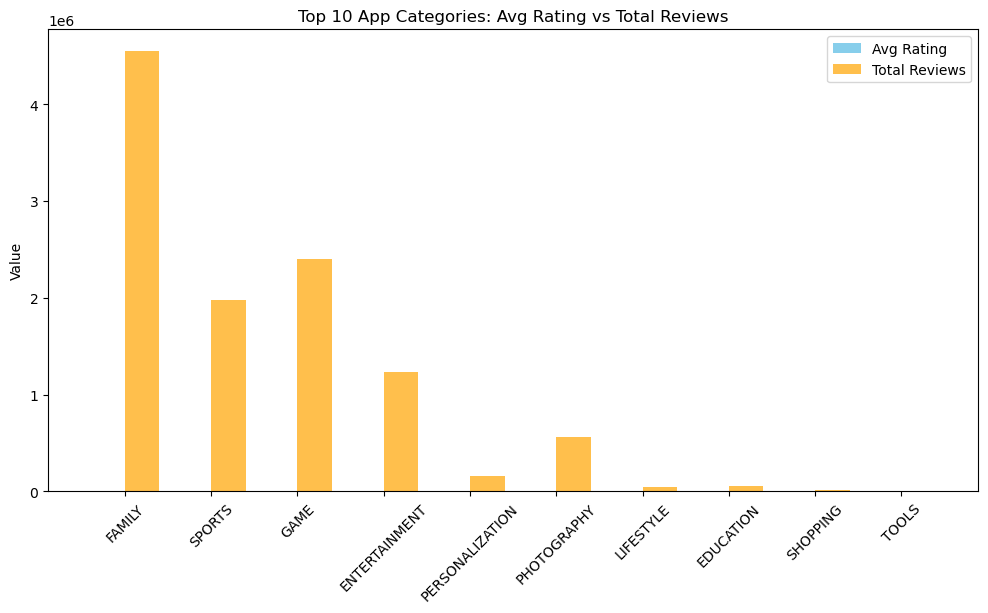

In [48]:
import matplotlib.pyplot as plt

# Create positions for the bars
x = range(len(top_categories))
width = 0.4  # width of each bar

# Plot
fig, ax = plt.subplots(figsize=(12,6))

# Bars for Avg Rating
ax.bar(x, top_categories['Rating'], width=width, label='Avg Rating', color='skyblue')

# Bars for Total Reviews (shifted by width)
ax.bar([i + width for i in x], top_categories['Reviews'], width=width, label='Total Reviews', color='orange', alpha=0.7)

# Labels
ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels(top_categories['Category'], rotation=45)
ax.set_ylabel('Value')
ax.set_title('Top 10 App Categories: Avg Rating vs Total Reviews')
ax.legend()

plt.show()


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

# Load dataset
df = pd.read_csv(r"C:\Users\rraks\Downloads\archive\googleplaystore.csv")

# --- Clean the 'Size' column ---
df['Size'] = df['Size'].replace('Varies with device', None)

# Remove rows with missing Size
df = df.dropna(subset=['Size'])

# Convert 'Size' to numeric (handle 'M' and 'k')
def convert_size(size):
    size = str(size).replace(',', '').strip()
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024  # convert KB to MB
    else:
        try:
            return float(size)
        except:
            return None

df['Size'] = df['Size'].apply(convert_size)

# --- Clean the 'Installs' column ---
df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df = df[df['Installs'].str.isnumeric()]  # remove rows with text like 'Free'
df['Installs'] = df['Installs'].astype(float)

# --- Clean the 'Reviews' column ---
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# --- Convert 'Last Updated' to datetime ---
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# --- Apply Filters as per Task ---
df_filtered = df[
    (df['Rating'] >= 4.0) &
    (df['Size'] >= 10) &
    (df['Last Updated'].dt.month == 1)
]

# --- Group and Aggregate ---
top_categories = (
    df_filtered.groupby('Category')
    .agg({'Rating': 'mean', 'Reviews': 'sum', 'Installs': 'sum'})
    .sort_values('Installs', ascending=False)
    .head(10)
    .reset_index()
)

# --- Time Control (3 PM - 5 PM IST) ---
ist = pytz.timezone('Asia/Kolkata')
ist_now = datetime.now(ist)
current_hour = ist_now.hour

# --- Plot Only if Time Matches ---
if 15 <= current_hour < 17:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(top_categories))
    width = 0.4

    ax.bar(x, top_categories['Rating'], width=width, label='Avg Rating', color='skyblue')
    ax.bar([i + width for i in x], top_categories['Reviews'], width=width, label='Total Reviews', color='orange', alpha=0.7)

    ax.set_xticks([i + width / 2 for i in x])
    ax.set_xticklabels(top_categories['Category'], rotation=45)
    ax.set_ylabel('Value')
    ax.set_title('Top 10 App Categories: Avg Rating vs Total Reviews')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Chart available only between 3 PM and 5 PM IST")


Chart available only between 3 PM and 5 PM IST


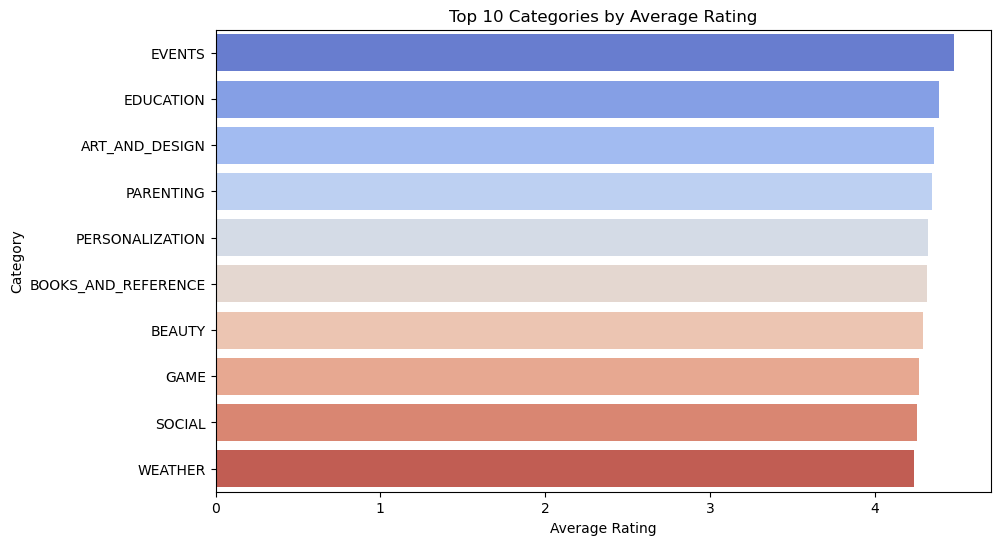

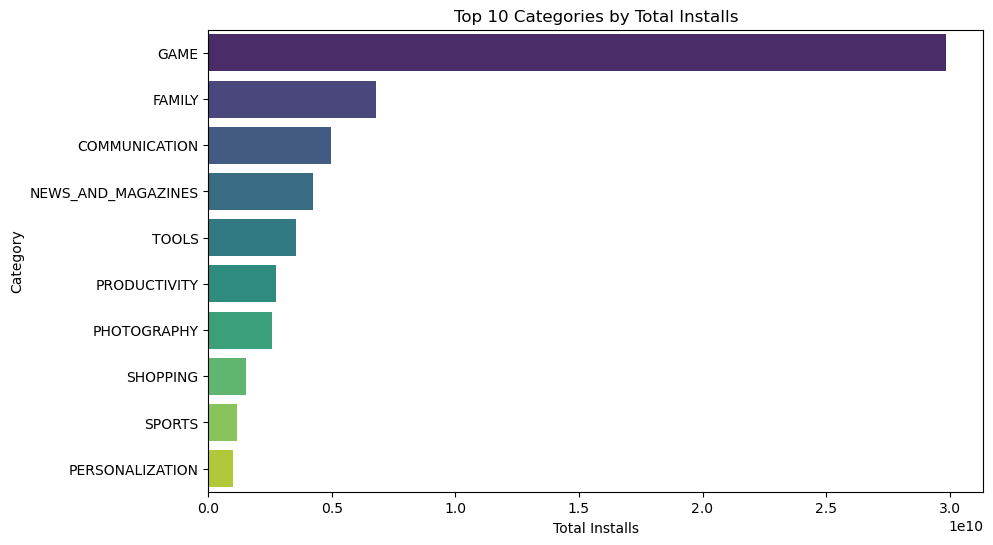

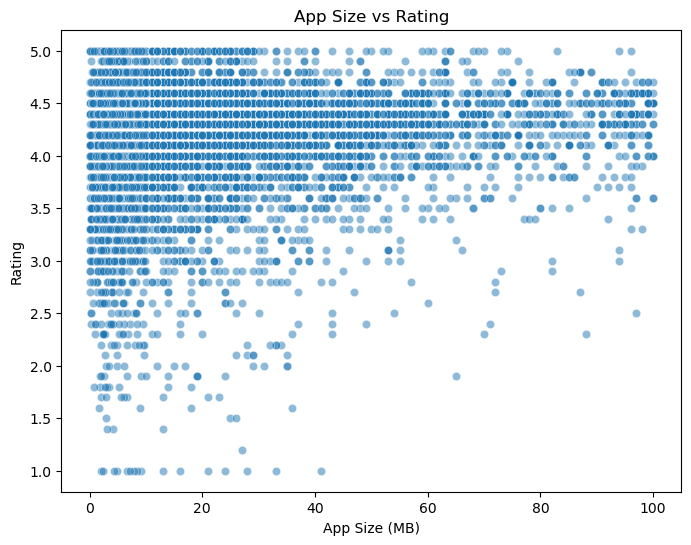

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️ Top 10 Categories by Average Rating ---
top_rating = (
    df.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_rating.values, y=top_rating.index, hue=top_rating.index, palette="coolwarm", legend=False)
plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.show()

# --- 2️ Top 10 Categories by Total Installs ---
top_installs = (
    df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_installs.values, y=top_installs.index, hue=top_installs.index, palette="viridis", legend=False)
plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Total Installs")
plt.ylabel("Category")
plt.show()

# --- 3️ Relationship between Size and Rating ---
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Size', y='Rating', alpha=0.5)
plt.title("App Size vs Rating")
plt.xlabel("App Size (MB)")
plt.ylabel("Rating")
plt.show()


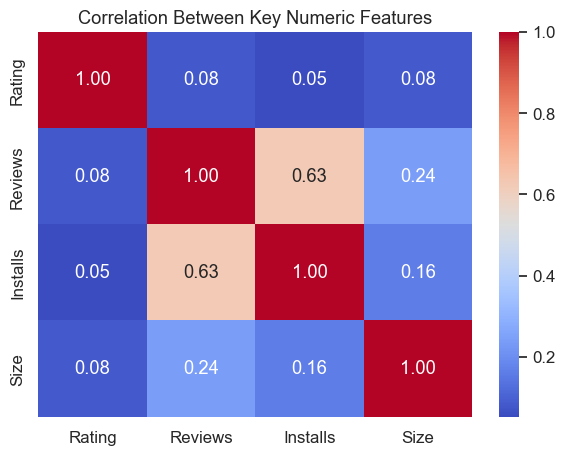

,Category,Avg_Rating,Total_Reviews,Total_Installs,Avg_Size_MB
0,FAMILY,4.395455,4544623,182494820.0,38.363636
1,SPORTS,4.342857,1982017,120511000.0,19.428571
2,GAME,4.313333,2397589,115691000.0,40.233333
3,ENTERTAINMENT,4.250000,1238948,51000000.0,25.833333
4,PERSONALIZATION,4.475000,155996,15060000.0,25.250000
5,PHOTOGRAPHY,4.150000,563720,10500000.0,41.000000
6,LIFESTYLE,4.380000,42809,5071000.0,19.000000
7,EDUCATION,4.400000,57645,2000000.0,74.000000
8,SHOPPING,4.200000,19950,2000000.0,18.000000
9,TOOLS,4.200000,8010,1010000.0,23.000000


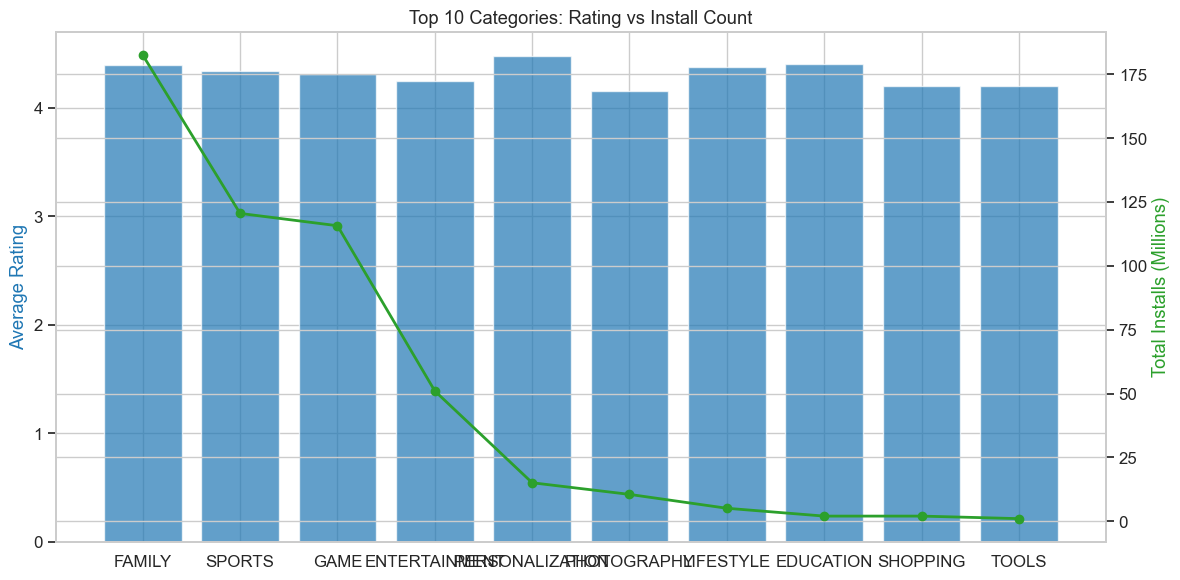

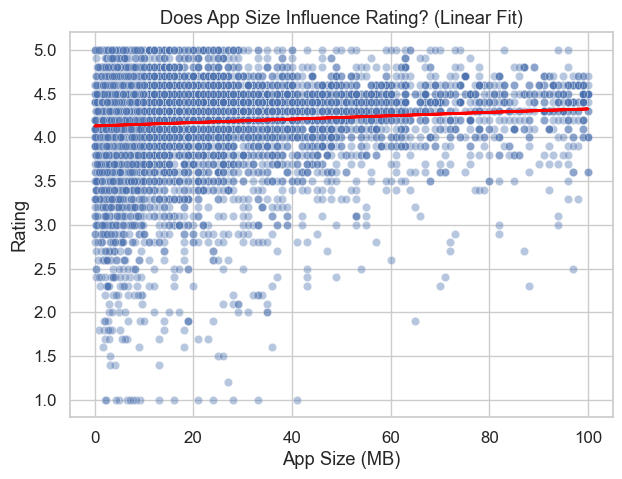

✅ Analysis complete — summary exported to top_category_performance.csv


In [7]:

import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# ---------- A. Correlation Heatmap ----------
numeric_df = df[['Rating', 'Reviews', 'Installs', 'Size']].dropna()
plt.figure(figsize=(7,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Key Numeric Features")
plt.show()

# ---------- B. Category Performance Summary ----------
cat_summary = (
    df_filtered.groupby('Category')
    .agg(Avg_Rating=('Rating', 'mean'),
         Total_Reviews=('Reviews', 'sum'),
         Total_Installs=('Installs', 'sum'),
         Avg_Size_MB=('Size', 'mean'))
    .sort_values('Total_Installs', ascending=False)
    .reset_index()
)

display(cat_summary.head(10))  # quick sanity check table

# ---------- C. Dual-Axis Chart: Installs vs Avg Rating ----------
top_installs_cat = cat_summary.head(10)

fig, ax1 = plt.subplots(figsize=(12,6))

color1 = 'tab:blue'
ax1.bar(top_installs_cat['Category'], top_installs_cat['Avg_Rating'],
        color=color1, alpha=0.7, label='Avg Rating')
ax1.set_ylabel('Average Rating', color=color1)

ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.plot(top_installs_cat['Category'], top_installs_cat['Total_Installs']/1e6,
         color=color2, marker='o', linewidth=2, label='Total Installs (Millions)')

ax2.set_ylabel('Total Installs (Millions)', color=color2)
plt.title("Top 10 Categories: Rating vs Install Count")
plt.xticks(rotation=40)
fig.tight_layout()
plt.show()

# See if Size predicts Rating (toy regression)
from sklearn.linear_model import LinearRegression
size_rating = df[['Size','Rating']].dropna()
X = size_rating[['Size']]
y = size_rating['Rating']

model = LinearRegression().fit(X, y)
pred = model.predict(X)

plt.figure(figsize=(7,5))
sns.scatterplot(x='Size', y='Rating', data=size_rating, alpha=0.4)
plt.plot(size_rating['Size'], pred, color='red', linewidth=2)
plt.title("Does App Size Influence Rating? (Linear Fit)")
plt.xlabel("App Size (MB)")
plt.ylabel("Rating")
plt.show()

# Save top category summary for report/dashboard
cat_summary.to_csv("top_category_performance.csv", index=False)
print("✅ Analysis complete — summary exported to top_category_performance.csv")

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\rraks\Downloads\archive\googleplaystore.csv")

# Function to convert Size to float
def size_to_float(size):
    if size == "Varies with device" or pd.isna(size):
        return None
    size = size.replace(",", "")  # remove commas
    if "M" in size:
        return float(size.replace("M",""))
    elif "k" in size:
        return float(size.replace("k","")) * 0.001
    else:
        try:
            return float(size)
        except:
            return None

# Apply the function
df['Size'] = df['Size'].apply(size_to_float)

# Drop rows where Size is NaN
df = df.dropna(subset=['Size'])

# Clean Installs column
df['Installs'] = df['Installs'].str.replace(',','').str.replace('+','').astype(float)

# Convert Reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Convert Last Updated to datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

print(df[['Size','Installs','Reviews','Last Updated']].head())


   Size    Installs  Reviews Last Updated
0  19.0     10000.0      159   2018-01-07
1  14.0    500000.0      967   2018-01-15
2   8.7   5000000.0    87510   2018-08-01
3  25.0  50000000.0   215644   2018-06-08
4   2.8    100000.0      967   2018-06-20
